In [1]:
import itertools
import os
import pickle
import numpy as np
import pandas as pd
from scipy.stats import iqr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
def flatten_dict(d, sep='_'):
    """
    Recursively flattens a nested dictionary, concatenating the outer and inner keys.

    Arguments
    -----------
    stats_dict: A nested dictionary of statistics
    sep: seperator for keys

    Returns
    ------------
    dict
    """

    def items():
        for key, value in d.items():
            if isinstance(value, dict):
                for subkey, subvalue in flatten_dict(value).items():
                    yield key + sep + subkey, subvalue
            else:
                yield key, value

    return dict(items())

In [3]:
def summary_stats(ts):
    pop_dict = {"domestic":0, "scot":1, "captive":2, "eu":3}

    stats = {
        "diversity": {},
        "segregating_sites": {},
        "tajimas_d": {},
        "divergence": {},
        "relatedness": {},
        "fst": {},
        "f2": {},
        "f3": {},
        "f4": {},
        "y2": {},
        "y3": {},
        "pc1_median":{},
        "pc2_median":{},
        "pc1_iqr":{},
        "pc2_iqr":{},
        "pc1_dist":{},
        "pc2_dist":{}
    }

    # One-way statistics
    for pop_name, pop_num in pop_dict.items():
        stats["diversity"][pop_name] = ts.diversity(sample_sets=ts.samples(population=pop_num))
        stats["segregating_sites"][pop_name] = ts.segregating_sites(sample_sets=ts.samples(population=pop_num))
        stats["tajimas_d"][pop_name] = ts.Tajimas_D(sample_sets=ts.samples(population=pop_num))

    # Two-way statistics
    for a, b in itertools.combinations(pop_dict.keys(), 2):
        key = f"{a}_{b}"
        stats["divergence"][key] = ts.divergence(sample_sets=[
            ts.samples(population=pop_dict[a]),
            ts.samples(population=pop_dict[b])
        ])
        stats["relatedness"][key] = ts.genetic_relatedness(sample_sets=[
            ts.samples(population=pop_dict[a]),
            ts.samples(population=pop_dict[b])
        ])
        stats["fst"][key] = ts.Fst(sample_sets=[
            ts.samples(population=pop_dict[a]),
            ts.samples(population=pop_dict[b])
        ])
        stats["f2"][key] = ts.f2(sample_sets=[
            ts.samples(population=pop_dict[a]),
            ts.samples(population=pop_dict[b])
        ])
        stats["y2"][key] = ts.Y2(sample_sets=[
            ts.samples(population=pop_dict[a]),
            ts.samples(population=pop_dict[b])
        ])

    # Three-way statistics
    for a in pop_dict.keys():
        for b, c in itertools.combinations([x for x in pop_dict.keys() if x != a], 2):
            key = f"{a}_{b}_{c}"
            stats["f3"][key] = ts.f3(sample_sets=[
                ts.samples(population=pop_dict[a]),
                ts.samples(population=pop_dict[b]),
                ts.samples(population=pop_dict[c])
            ])
            stats["y3"][key] = ts.Y3(sample_sets=[
                ts.samples(population=pop_dict[a]),
                ts.samples(population=pop_dict[b]),
                ts.samples(population=pop_dict[c])
            ])

    # Four-way statistics (all meaningful F4 combinations)
    for a, b, c, d in itertools.combinations(pop_dict.keys(), 4):
        # Three unique F4 configurations per 4 populations
        f4_configs = [
            (a, b, c, d),
            (a, c, b, d),
            (a, d, b, c)
        ]
        for w, x, y, z in f4_configs:
            key = f"{w}_{x}_{y}_{z}"
            stats["f4"][key] = ts.f4(sample_sets=[
                ts.samples(population=pop_dict[w]),
                ts.samples(population=pop_dict[x]),
                ts.samples(population=pop_dict[y]),
                ts.samples(population=pop_dict[z])
            ])

    ##### PCA summary stats #####
    genotype = ts.genotype_matrix()
    samples = genotype.shape[1]
    ones = list(range(0, samples, 2))
    twos = list(range(1, samples, 2))
    matrix_012 = genotype[:, ones] + genotype[:, twos]
    standardizedData = StandardScaler().fit_transform(matrix_012.T)
    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(standardizedData)
    pca_df = pd.DataFrame(principalComponents, columns=['pc1', 'pc2'])

    # UPDATED population labels
    pops = (
        ["domestic"] * 6 +
        ["scot"] * 16 +
        ["captive"] * 10 +
        ["eu"] * 14
    )
    pca_df["pop"] = pops
    pop_names = ["domestic", "scot", "captive", "eu"]

    stats_df = pca_df.groupby("pop").agg((np.median, iqr))
    stats_dict = stats_df.to_dict()

    for pop in pop_names:
        stats["pc1_median"][pop] = stats_dict[('pc1', 'median')][pop]
        stats["pc2_median"][pop] = stats_dict[('pc2', 'median')][pop]
        stats["pc1_iqr"][pop] = stats_dict[('pc1', 'iqr')][pop]
        stats["pc2_iqr"][pop] = stats_dict[('pc2', 'iqr')][pop]

    # Pairwise PCA distances
    for comparison in [
        "domestic_scot",
        "domestic_captive",
        "domestic_eu",
        "scot_captive",
        "scot_eu",
        "captive_eu"
    ]:
        a, b = comparison.split("_")
        stats["pc1_dist"][comparison] = abs(
            stats_dict[('pc1', 'median')][a] - stats_dict[('pc1', 'median')][b]
        )
        stats["pc2_dist"][comparison] = abs(
            stats_dict[('pc2', 'median')][a] - stats_dict[('pc2', 'median')][b]
        )

    # Save flattened stats
    ref_table = pd.DataFrame(flatten_dict(stats), index=['i'])

    return ref_table, pca_df

In [4]:
ts = pd.read_pickle(r'./tsinfer_tree_2.pickle')

In [5]:
ref_table, pca = summary_stats(ts)
ref_table.to_csv("./observed_stats.csv", index = False)

/var/folders/ty/5bvjyd1n4dx2ymnhbn1s9579brngf7/T/ipykernel_65468/1536165260.py:107: FutureWarning: The provided callable <function median at 0x1082abba0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  stats_df = pca_df.groupby("pop").agg((np.median, iqr))
/var/folders/ty/5bvjyd1n4dx2ymnhbn1s9579brngf7/T/ipykernel_65468/1536165260.py:107: FutureWarning: The provided callable <function median at 0x1082abba0> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  stats_df = pca_df.groupby("pop").agg((np.median, iqr))


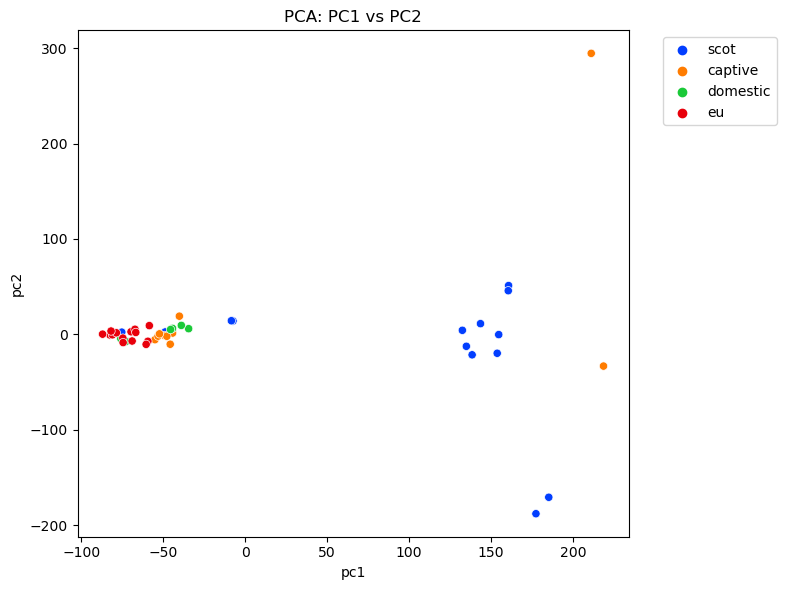

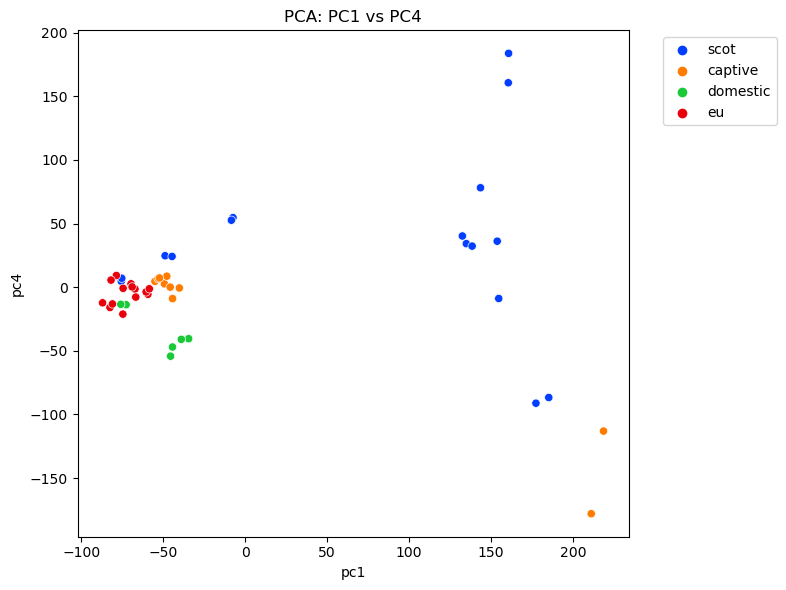

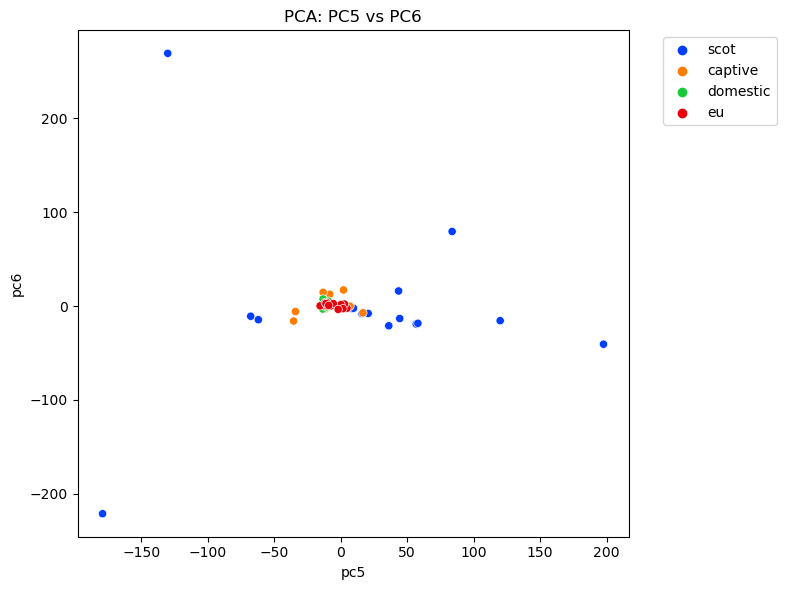

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import numpy as np
import seaborn as sns
import pandas as pd
from samples_dict import samples_dict
import matplotlib.pyplot as plt

##### PCA summary stats #####
genotype = ts.genotype_matrix()


# convert from 01 to 012
samples = np.shape(genotype)[1]
ones = [i for i in range(0, samples, 2)]
twos = [i for i in range(1, samples, 2)]

matrix_012 = np.add(genotype[:, ones], genotype[:, twos])

# scaled PCA with first 4 PCs
pipeline = Pipeline([('scaling', StandardScaler()), ('pca', PCA(n_components=6))])
principalComponents = pipeline.fit_transform(matrix_012.T)

pca_df = pd.DataFrame(principalComponents, columns=['pc1', 'pc2', 'pc3', 'pc4', 'pc5', 'pc6'])
pca_df["pop"] = list(samples_dict.values())

# PC1 vs PC2 plot
plt.figure(figsize=(8,6))
ax1 = sns.scatterplot(data=pca_df, x='pc1', y='pc2', hue='pop', palette="bright")
ax1.set_title("PCA: PC1 vs PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# PC3 vs PC4 plot
plt.figure(figsize=(8,6))
ax2 = sns.scatterplot(data=pca_df, x='pc1', y='pc4', hue='pop', palette="bright")
ax2.set_title("PCA: PC1 vs PC4")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# PC5 vs PC6 plot
plt.figure(figsize=(8,6))
ax2 = sns.scatterplot(data=pca_df, x='pc5', y='pc6', hue='pop', palette="bright")
ax2.set_title("PCA: PC5 vs PC6")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()
